<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/gasvaluechain/useOfNaturalGas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Use of natural gas: history, present, outlook, and NeqSim application

**Evidence updated:** 23 July 2026  
**Intended audience:** energy analysts, process engineers, and students who know basic Python.

This notebook preserves the original Norwegian production and export examples, repairs their
offline reproducibility, and places them inside a current evidence-to-engineering workflow.

## Learning objectives

After completing the notebook, you can:

1. distinguish observed statistics, forecasts, scenarios, and engineering assumptions;
2. explain how natural-gas use developed and where gas is used today;
3. reproduce the original Norwegian production and export analyses without fragile downloads;
4. calculate growth, energy, and useful-energy quantities with explicit units;
5. create a representative export-gas fluid in NeqSim and run a TP flash;
6. calculate ISO 6976 calorific values and Wobbe index;
7. connect a NeqSim stream, compressor, and aftercooler in a `ProcessSystem`;
8. retrieve equipment results and verify mass and energy balances; and
9. translate gas statistics into transparent engineering screening results.

## Prerequisites, scope, and evidence discipline

Python, pandas, NumPy, matplotlib, and the public `neqsim` package are sufficient. All datasets
used by the code are embedded so the notebook remains reproducible offline.

The notebook uses four evidence labels:

- **Observation:** a measured or reported historical value.
- **Forecast:** a time-bounded expectation conditional on current information.
- **Scenario:** a coherent pathway, not a prediction.
- **Screening assumption:** an engineering input chosen for sensitivity analysis.

Statistics are not mixed with thermodynamic model output. NeqSim converts a stated composition
and process boundary into properties and equipment results; it does not forecast energy demand.

In [1]:
import importlib.metadata
import subprocess
import sys

required_neqsim_version = "3.16.0"
installed_version = importlib.metadata.version("neqsim")

if installed_version != required_neqsim_version:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )
    installed_version = importlib.metadata.version("neqsim")

print(f"NeqSim version: {installed_version}")
print(f"Python version: {sys.version.split()[0]}")

NeqSim version: 3.16.0
Python version: 3.12.13


In [2]:
import math
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from neqsim.process import compressor, cooler, newProcess, stream
from neqsim.thermo import ISO6976, TPflash, fluid

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "grey": "#666666",
}

print(f"Platform: {platform.platform()}")

Platform: Linux-6.12.13-x86_64-with-glibc2.39


## 1. Historical development

Natural gas moved from local seep collection and town-gas lighting to regional pipeline systems,
then to global LNG trade. Its modern roles include:

- space and water heating;
- dispatchable electricity generation;
- high-temperature industrial heat;
- feedstock for ammonia, methanol, and hydrogen;
- fuel and process gas in petroleum operations; and
- a source of flexibility in energy systems with variable renewable generation.

The value chain matters: production, processing, pipeline transport, LNG liquefaction and
shipping, distribution, and end use each add energy demand and potential methane emissions.

## 2. Present market: growth slowed after 2024

The IEA reported that global demand increased by 2.7%, or 115 bcm, in 2024. Growth slowed to
about 1%, or 40 bcm, in 2025. The IEA's Q3-2026 forecast, published under unusually disrupted
market conditions, expected 2026 demand to decline by about 0.5%, or 20 bcm.

These are successive vintages of evidence. The 2026 value is a **forecast**, not an observation,
and should be replaced when final annual data become available.

For annual change $g_t$:

$$
g_t = 100\frac{D_t-D_{t-1}}{D_{t-1}}
$$

$D_t$ is demand in year $t$ in bcm and $g_t$ is percent per year.

In [3]:
global_change = pd.DataFrame(
    {
        "year": [2024, 2025, 2026],
        "change_bcm": [115.0, 40.0, -20.0],
        "change_percent": [2.7, 1.0, -0.5],
        "evidence": ["Observation", "Observation", "IEA Q3 forecast"],
    }
)

display(global_change)

assert global_change.loc[0, "change_bcm"] > global_change.loc[1, "change_bcm"]
assert global_change.loc[2, "evidence"] == "IEA Q3 forecast"

,year,change_bcm,change_percent,evidence
0,2024,115.0,2.7,Observation
1,2025,40.0,1.0,Observation
2,2026,-20.0,-0.5,IEA Q3 forecast


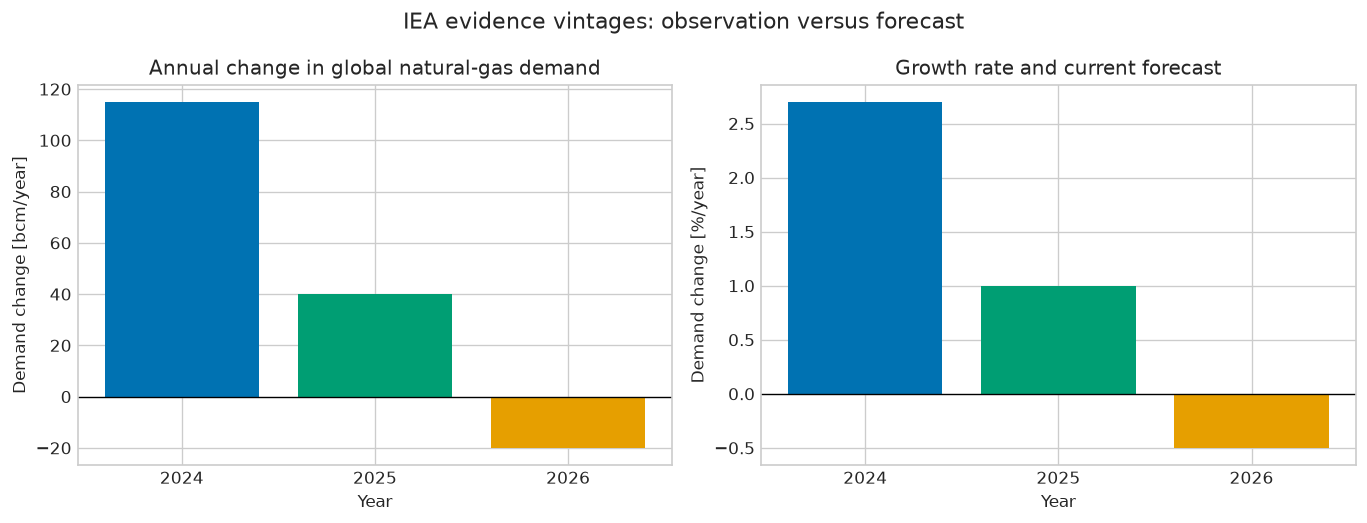

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

bar_colors = [
    COLORS["blue"],
    COLORS["green"],
    COLORS["orange"],
]
axes[0].bar(
    global_change["year"].astype(str),
    global_change["change_bcm"],
    color=bar_colors,
)
axes[0].axhline(0.0, color="black", linewidth=0.8)
axes[0].set_title("Annual change in global natural-gas demand")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Demand change [bcm/year]")

axes[1].bar(
    global_change["year"].astype(str),
    global_change["change_percent"],
    color=bar_colors,
)
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set_title("Growth rate and current forecast")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Demand change [%/year]")

fig.suptitle("IEA evidence vintages: observation versus forecast", fontsize=13)
fig.tight_layout()
plt.show()

**Interpretation.** The market did not follow a single smooth trend. Strong 2024 growth was
followed by slower 2025 growth, while the current 2026 forecast is negative. Weather, prices,
industrial activity, hydropower availability, infrastructure, and geopolitical disruption can
move annual gas use materially.

## 3. Where gas is used

The same gas molecule may become useful heat, electricity, hydrogen, ammonia, or petrochemical
feedstock. Comparing volumes alone hides conversion efficiency.

Useful energy $E_u$ is screened from fuel energy $E_f$ and end-use efficiency $\eta$:

$$
E_u = \eta E_f
$$

Efficiency is dimensionless. Fuel and useful energy use the same unit, here petajoules.
The values below are transparent screening assumptions, not universal technology benchmarks.

In [5]:
end_uses = pd.DataFrame(
    {
        "end_use": [
            "Condensing heat",
            "Combined-cycle power",
            "Industrial furnace",
            "Hydrogen via SMR",
        ],
        "efficiency": [0.92, 0.58, 0.82, 0.74],
        "basis": [
            "Useful heat / LHV",
            "Net electricity / LHV",
            "Useful heat / LHV",
            "Hydrogen LHV / gas LHV",
        ],
    }
)
end_uses["useful_energy_pj_per_100_pj"] = 100.0 * end_uses["efficiency"]

display(end_uses)

assert end_uses["efficiency"].between(0.0, 1.0).all()

,end_use,efficiency,basis,useful_energy_pj_per_100_pj
0,Condensing heat,0.92,Useful heat / LHV,92.0
1,Combined-cycle power,0.58,Net electricity / LHV,58.0
2,Industrial furnace,0.82,Useful heat / LHV,82.0
3,Hydrogen via SMR,0.74,Hydrogen LHV / gas LHV,74.0


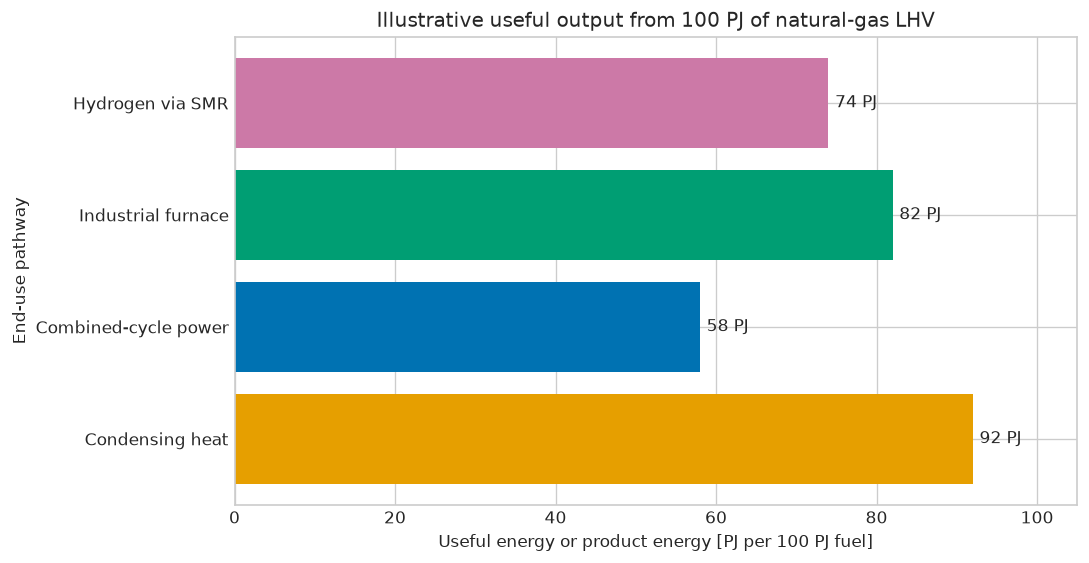

In [6]:
fig, ax = plt.subplots(figsize=(9.2, 4.8))

bars = ax.barh(
    end_uses["end_use"],
    end_uses["useful_energy_pj_per_100_pj"],
    color=[
        COLORS["orange"],
        COLORS["blue"],
        COLORS["green"],
        COLORS["purple"],
    ],
)
ax.bar_label(bars, fmt="%.0f PJ", padding=4)
ax.set_xlim(0.0, 105.0)
ax.set_title("Illustrative useful output from 100 PJ of natural-gas LHV")
ax.set_xlabel("Useful energy or product energy [PJ per 100 PJ fuel]")
ax.set_ylabel("End-use pathway")
plt.tight_layout()
plt.show()

**Interpretation.** End-use service, technology, operating point, and boundary definition determine
the conversion result. A high boiler efficiency does not make gas carbon-free, and hydrogen
screening must also include process CO2, methane, capture rate, electricity, and upstream energy.

## 4. Preservation checklist for the original notebook

The legacy workbook contained five substantive items, all retained here:

1. history, present use, and future considerations;
2. Norwegian Continental Shelf (NCS) production analysis;
3. Norwegian crude-oil, NGL, and condensate export destinations;
4. a 2019 comparison of major net gas exporters; and
5. Norwegian gas exports by first delivery point.

The three export charts remain explicitly labelled as **historical snapshots**. Their embedded
values were the notebook's original offline fallbacks; they are not presented as current data.

## 5. Original NCS production example, repaired

The old cell downloaded a CSV from a retired NPD ReportServer URL. The preserved 2015–2020
fallback data are embedded below, with the original four production series and units. Current
official gas-sales observations are then added separately: 124 bcm in 2024 and 121.8 bcm in 2025.

Oil, NGL, and total production are in million standard cubic metres of oil equivalent
($\mathrm{MSm^3\ o.e.}$). Gas is plotted on its original numerical basis of bcm.

In [7]:
ncs_legacy = pd.DataFrame(
    {
        "year": [2015, 2016, 2017, 2018, 2019, 2020],
        "oil_msm3_oe": [90.6, 92.0, 86.5, 82.7, 78.3, 85.2],
        "gas_bcm": [117.2, 116.8, 123.2, 121.7, 115.2, 112.3],
        "ngl_msm3_oe": [19.2, 18.6, 18.2, 17.0, 16.3, 15.9],
        "total_msm3_oe": [227.0, 227.4, 227.9, 221.4, 209.8, 213.4],
    }
)

ncs_current_gas = pd.DataFrame(
    {
        "year": [2024, 2025],
        "gas_sales_bcm": [124.0, 121.8],
        "status": ["Final official summary", "Preliminary annual total"],
    }
)

display(ncs_legacy)
display(ncs_current_gas)

assert math.isclose(ncs_current_gas["gas_sales_bcm"].iloc[0], 124.0)
assert ncs_current_gas["gas_sales_bcm"].iloc[1] > 120.0

,year,oil_msm3_oe,gas_bcm,ngl_msm3_oe,total_msm3_oe
0,2015,90.6,117.2,19.2,227.0
1,2016,92.0,116.8,18.6,227.4
2,2017,86.5,123.2,18.2,227.9
3,2018,82.7,121.7,17.0,221.4
4,2019,78.3,115.2,16.3,209.8
5,2020,85.2,112.3,15.9,213.4


,year,gas_sales_bcm,status
0,2024,124.0,Final official summary
1,2025,121.8,Preliminary annual total


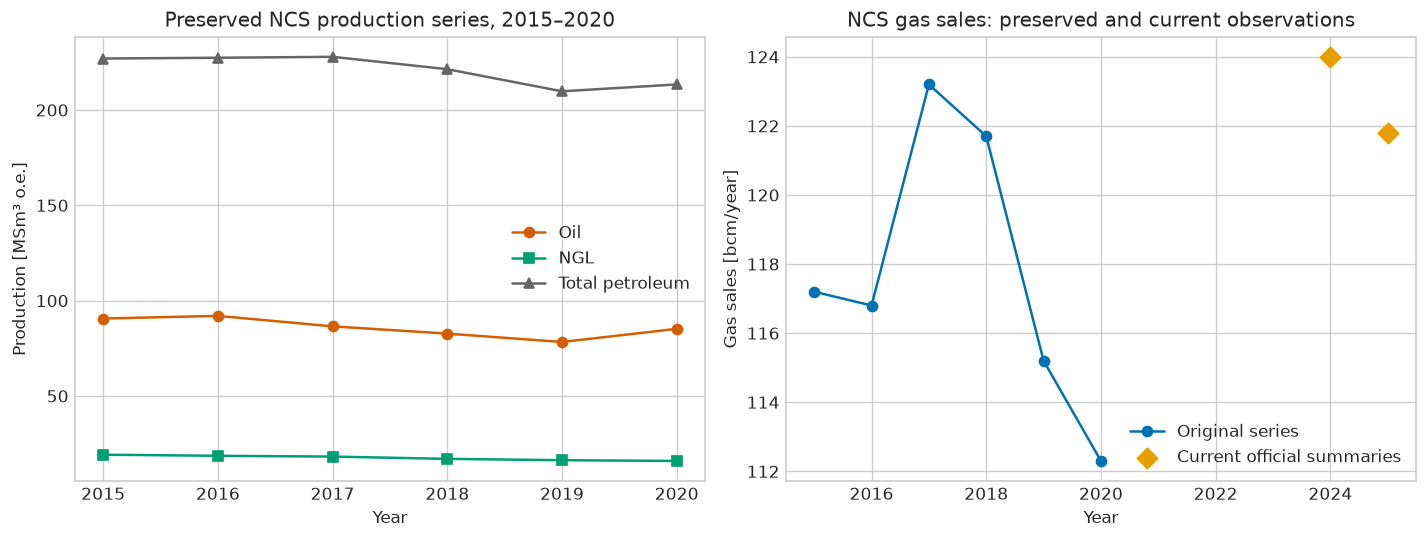

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))

axes[0].plot(
    ncs_legacy["year"],
    ncs_legacy["oil_msm3_oe"],
    marker="o",
    label="Oil",
    color=COLORS["red"],
)
axes[0].plot(
    ncs_legacy["year"],
    ncs_legacy["ngl_msm3_oe"],
    marker="s",
    label="NGL",
    color=COLORS["green"],
)
axes[0].plot(
    ncs_legacy["year"],
    ncs_legacy["total_msm3_oe"],
    marker="^",
    label="Total petroleum",
    color=COLORS["grey"],
)
axes[0].set_title("Preserved NCS production series, 2015–2020")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Production [MSm³ o.e.]")
axes[0].legend()

axes[1].plot(
    ncs_legacy["year"],
    ncs_legacy["gas_bcm"],
    marker="o",
    label="Original series",
    color=COLORS["blue"],
)
axes[1].scatter(
    ncs_current_gas["year"],
    ncs_current_gas["gas_sales_bcm"],
    s=75,
    marker="D",
    label="Current official summaries",
    color=COLORS["orange"],
)
axes[1].set_title("NCS gas sales: preserved and current observations")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Gas sales [bcm/year]")
axes[1].legend()

fig.tight_layout()
plt.show()

**Interpretation.** The current official total declined from the 2024 record but remained near
120 bcm in 2025. The Norwegian Offshore Directorate expects approximately this level for the next
three to four years, while warning that production declines later in the decade without sufficient
investment and new developments.

## 6. Original crude, NGL, and condensate export example

This chart preserves the original six-category offline dataset. It represents the historical
workbook snapshot used by the legacy notebook and is retained for teaching categorical shares.
It must not be used as a 2026 trade statement.

In [9]:
liquid_export_snapshot = pd.DataFrame(
    {
        "delivery_point": [
            "UK",
            "Netherlands",
            "Germany",
            "Sweden",
            "Denmark",
            "Other",
        ],
        "share_percent": [28.0, 22.0, 18.0, 13.0, 8.0, 11.0],
    }
)

assert math.isclose(liquid_export_snapshot["share_percent"].sum(), 100.0)
display(liquid_export_snapshot)

,delivery_point,share_percent
0,UK,28.0
1,Netherlands,22.0
2,Germany,18.0
3,Sweden,13.0
4,Denmark,8.0
5,Other,11.0


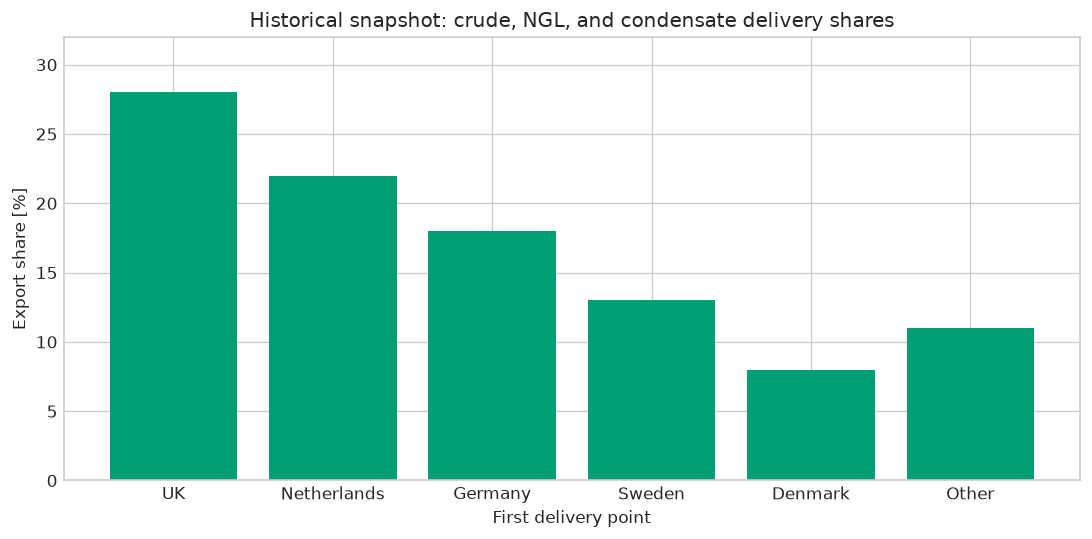

In [10]:
fig, ax = plt.subplots(figsize=(9.2, 4.6))

ax.bar(
    liquid_export_snapshot["delivery_point"],
    liquid_export_snapshot["share_percent"],
    color=COLORS["green"],
)
ax.set_title("Historical snapshot: crude, NGL, and condensate delivery shares")
ax.set_xlabel("First delivery point")
ax.set_ylabel("Export share [%]")
ax.set_ylim(0.0, 32.0)
plt.tight_layout()
plt.show()

## 7. Original 2019 net gas-exporter comparison

The original comparison is preserved as a dated snapshot. Definitions of “net export,” standard
conditions, LNG treatment, and calendar year must be aligned before combining trade datasets.

In [11]:
gas_exporter_2019 = pd.DataFrame(
    {
        "exporter": [
            "Russia",
            "Qatar",
            "Norway",
            "Australia",
            "USA",
            "Algeria",
        ],
        "net_export_bcm": [223.0, 128.0, 112.0, 105.0, 61.0, 52.0],
    }
)

display(gas_exporter_2019)

assert (gas_exporter_2019["net_export_bcm"] > 0.0).all()

,exporter,net_export_bcm
0,Russia,223.0
1,Qatar,128.0
2,Norway,112.0
3,Australia,105.0
4,USA,61.0
5,Algeria,52.0


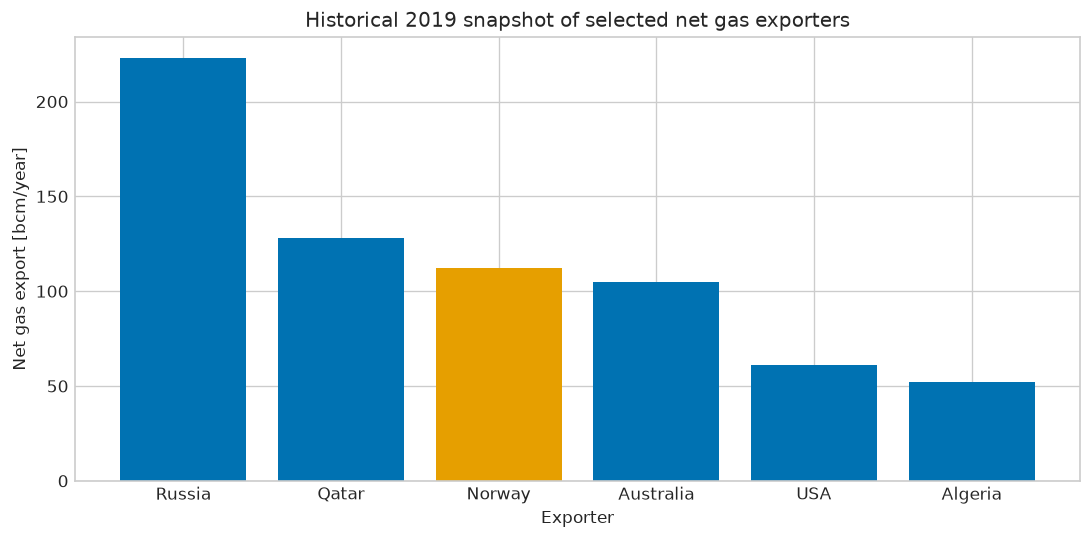

In [12]:
fig, ax = plt.subplots(figsize=(9.2, 4.6))

colors = [
    COLORS["orange"] if name == "Norway" else COLORS["blue"]
    for name in gas_exporter_2019["exporter"]
]
ax.bar(
    gas_exporter_2019["exporter"],
    gas_exporter_2019["net_export_bcm"],
    color=colors,
)
ax.set_title("Historical 2019 snapshot of selected net gas exporters")
ax.set_xlabel("Exporter")
ax.set_ylabel("Net gas export [bcm/year]")
plt.tight_layout()
plt.show()

## 8. Original Norwegian gas-delivery example

The final legacy chart is also retained with its original six-category sample. It teaches
destination analysis but remains a historical 2013–2019-era snapshot.

In [13]:
gas_delivery_snapshot = pd.DataFrame(
    {
        "delivery_point": [
            "Germany",
            "UK",
            "France",
            "Belgium",
            "Netherlands",
            "Other",
        ],
        "gas_bcm": [42.0, 25.0, 15.0, 9.0, 7.0, 6.0],
    }
)

display(gas_delivery_snapshot)

assert gas_delivery_snapshot["gas_bcm"].sum() > 100.0

,delivery_point,gas_bcm
0,Germany,42.0
1,UK,25.0
2,France,15.0
3,Belgium,9.0
4,Netherlands,7.0
5,Other,6.0


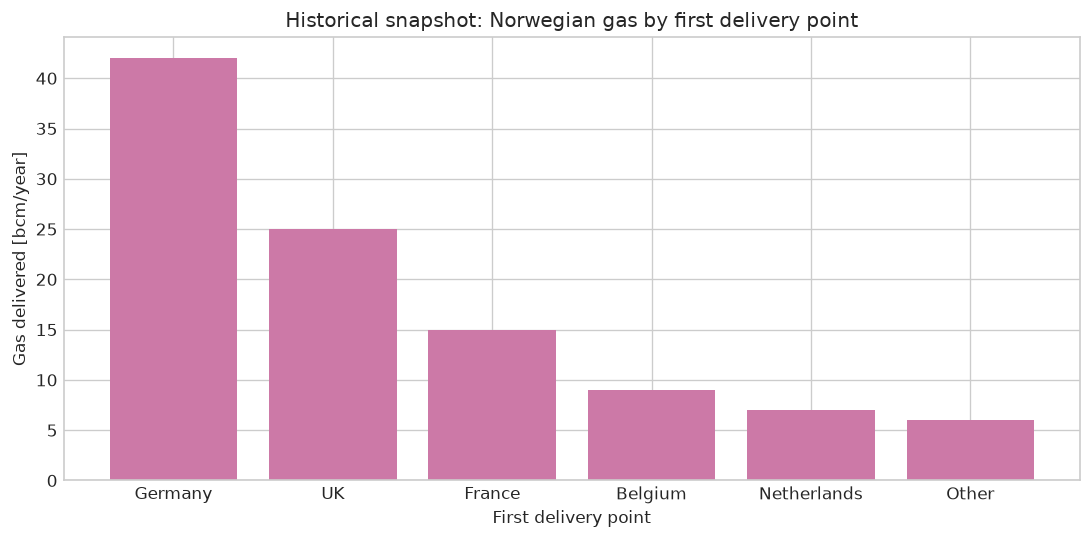

In [14]:
fig, ax = plt.subplots(figsize=(9.2, 4.6))

ax.bar(
    gas_delivery_snapshot["delivery_point"],
    gas_delivery_snapshot["gas_bcm"],
    color=COLORS["purple"],
)
ax.set_title("Historical snapshot: Norwegian gas by first delivery point")
ax.set_xlabel("First delivery point")
ax.set_ylabel("Gas delivered [bcm/year]")
plt.tight_layout()
plt.show()

## 9. Current resource context

The Norwegian Offshore Directorate's Resource Accounts for 2025 reported total gas resources,
including volumes already sold and delivered, of 6,685 bcm. Resource volume is not the same as
reserves, annual production, economic supply, or climate-compatible demand.

The accounts distinguish produced volumes, reserves, contingent resources, and undiscovered
resources. Those categories have different maturity and uncertainty.

In [15]:
ncs_resource_context = pd.DataFrame(
    {
        "metric": [
            "Gas resources including produced volume",
            "Gas sold in 2025",
            "Gas sold in 2024",
        ],
        "value_bcm": [6685.0, 121.8, 124.0],
        "evidence_date": ["2026-02-20", "2026-01-20", "2025-01-09"],
    }
)
ncs_resource_context["share_of_total_percent"] = (
    100.0
    * ncs_resource_context["value_bcm"]
    / ncs_resource_context["value_bcm"].iloc[0]
)

display(ncs_resource_context)

assert ncs_resource_context["value_bcm"].iloc[0] > 50.0 * 121.8

,metric,value_bcm,evidence_date,share_of_total_percent
0,Gas resources including produced volume,6685.0,2026-02-20,100.000000
1,Gas sold in 2025,121.8,2026-01-20,1.821990
2,Gas sold in 2024,124.0,2025-01-09,1.854899


## 10. Future use: conditional pathways, not a single prediction

Future gas use depends on efficiency, electrification, renewables, nuclear power, coal-to-gas
switching, carbon capture, low-emissions gases, methane policy, energy security, prices, and
industrial structure. Short-run forecasts can differ sharply from long-run scenarios.

A compound annual growth rate over $n$ years is:

$$
\mathrm{CAGR} = \left(\frac{D_n}{D_0}\right)^{1/n} - 1
$$

$D_0$ and $D_n$ must use the same boundary and unit. CAGR smooths variability and should not be
mistaken for an annual forecast.

In [16]:
illustrative_index = pd.DataFrame(
    {
        "year": [2025, 2030, 2035, 2040, 2045, 2050],
        "efficiency_led": [100, 96, 91, 85, 78, 70],
        "security_plateau": [100, 101, 101, 100, 97, 92],
        "high_electrification": [100, 91, 80, 68, 56, 45],
    }
)

years = illustrative_index["year"].iloc[-1] - illustrative_index["year"].iloc[0]
cagr = (
    illustrative_index["high_electrification"].iloc[-1]
    / illustrative_index["high_electrification"].iloc[0]
) ** (1.0 / years) - 1.0

print(f"Illustrative high-electrification CAGR: {100.0 * cagr:.3f} %/year")

assert cagr < 0.0

Illustrative high-electrification CAGR: -3.144 %/year


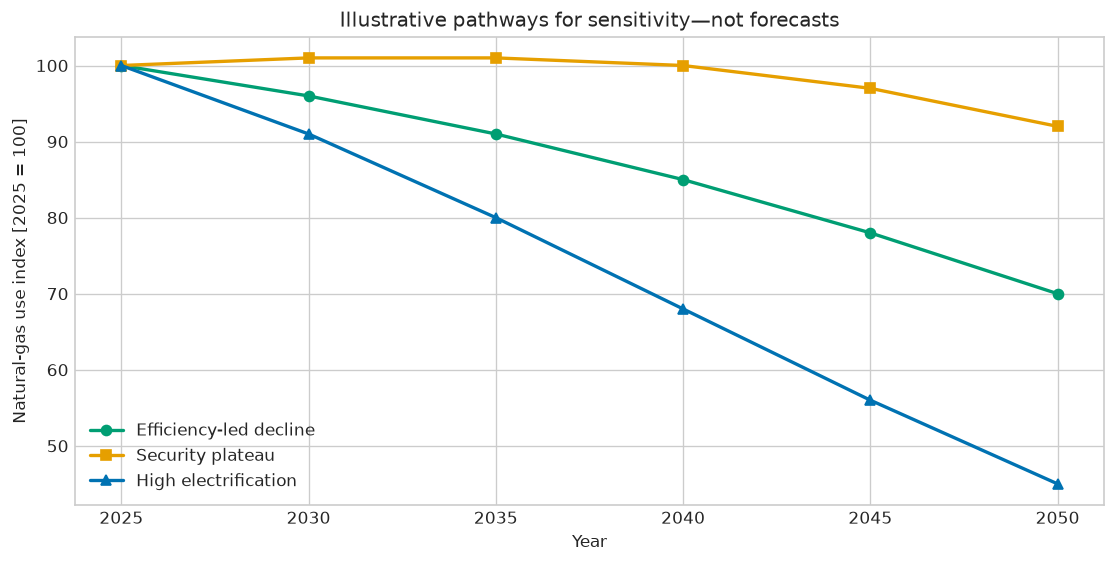

In [17]:
fig, ax = plt.subplots(figsize=(9.4, 4.8))

scenario_styles = [
    ("efficiency_led", "Efficiency-led decline", COLORS["green"], "o"),
    ("security_plateau", "Security plateau", COLORS["orange"], "s"),
    (
        "high_electrification",
        "High electrification",
        COLORS["blue"],
        "^",
    ),
]
for column, label, color, marker in scenario_styles:
    ax.plot(
        illustrative_index["year"],
        illustrative_index[column],
        marker=marker,
        linewidth=2.0,
        label=label,
        color=color,
    )

ax.set_title("Illustrative pathways for sensitivity—not forecasts")
ax.set_xlabel("Year")
ax.set_ylabel("Natural-gas use index [2025 = 100]")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation.** The chart is deliberately indexed and labelled illustrative. It is a reusable
uncertainty frame, not an IEA projection. Analysts can replace the indices with a licensed or
public scenario dataset while preserving the calculations and labels.

# Practical NeqSim application: from export gas to delivered energy

The final section demonstrates real NeqSim functionality:

1. define an export-gas composition and SRK thermodynamic model;
2. perform a TP flash and inspect phase state;
3. calculate ISO 6976 calorific values and Wobbe index;
4. create a named material stream at 100 kg/s;
5. connect a compressor and aftercooler inside a `ProcessSystem`;
6. run the process and retrieve temperatures, power, duty, and flow;
7. verify mass and compressor energy closure; and
8. convert the 2025 Norwegian gas-sales statistic to an energy screen.

SRK is appropriate for a dry, non-polar hydrocarbon-rich gas in this screening range. A model
including water association is needed for wet-gas and dehydration studies.

## 11. Define the representative fluid

Composition is a reproducible teaching assumption in mole fraction. It is not a custody-transfer
sample. Temperature is 288.15 K and pressure is 70 bara.

The component sum must be one:

$$
\sum_i z_i = 1
$$

$z_i$ is component $i$'s mole fraction.

In [18]:
composition = {
    "methane": 0.900,
    "ethane": 0.050,
    "propane": 0.020,
    "n-butane": 0.005,
    "nitrogen": 0.015,
    "CO2": 0.010,
}

composition_sum = sum(composition.values())
assert math.isclose(composition_sum, 1.0, rel_tol=0.0, abs_tol=1.0e-12)

export_gas = fluid(
    "srk",
    temperature=288.15,
    pressure=70.0,
)
for component_name, mole_fraction in composition.items():
    export_gas.addComponent(
        component_name,
        mole_fraction,
    )

export_gas.setMixingRule("classic")
TPflash(export_gas)

phase_count = export_gas.getNumberOfPhases()
print(f"Composition sum: {composition_sum:.6f} mol/mol")
print(f"Equilibrium phase count: {phase_count}")

assert phase_count == 1

Composition sum: 1.000000 mol/mol
Equilibrium phase count: 1


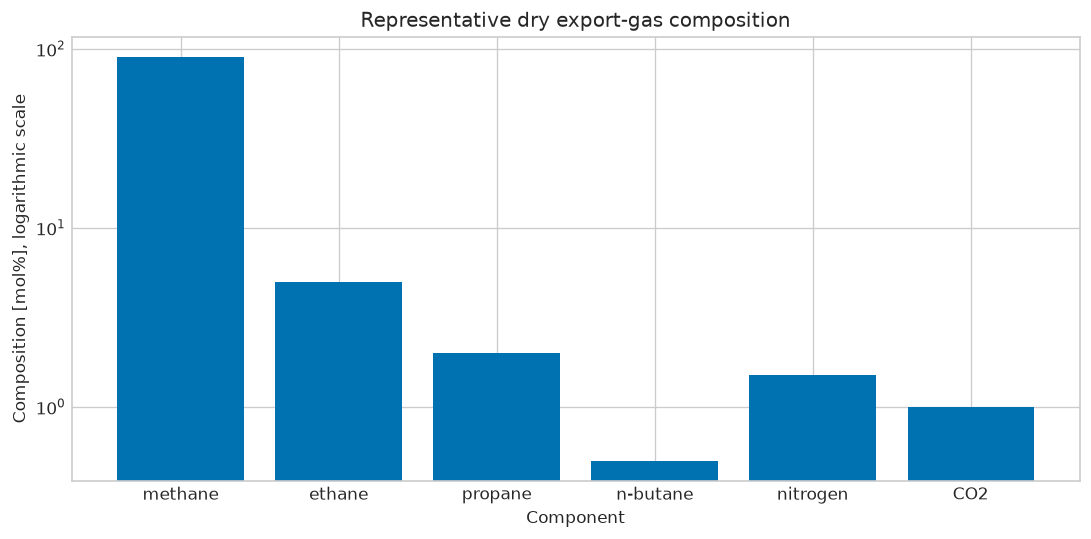

In [19]:
composition_table = pd.DataFrame(
    {
        "component": list(composition.keys()),
        "mole_percent": 100.0 * np.array(list(composition.values())),
    }
)

fig, ax = plt.subplots(figsize=(9.2, 4.6))

ax.bar(
    composition_table["component"],
    composition_table["mole_percent"],
    color=COLORS["blue"],
)
ax.set_yscale("log")
ax.set_title("Representative dry export-gas composition")
ax.set_xlabel("Component")
ax.set_ylabel("Composition [mol%], logarithmic scale")
plt.tight_layout()
plt.show()

**Interpretation.** Methane dominates, while ethane and propane materially increase calorific
value. Nitrogen and carbon dioxide are non-combustible diluents in ISO 6976 calculations.

## 12. ISO 6976 gas quality

ISO 6976 converts composition and reference conditions into calorific values, relative density,
and Wobbe index. Volume results use 15°C reference conditions and standard cubic metres.

Energy represented by standard volume is:

$$
E_f = V_s H_{i,s}
$$

$V_s$ is standard volume in $\mathrm{Sm^3}$ and $H_{i,s}$ is inferior calorific value in
$\mathrm{MJ/Sm^3}$.

In [20]:
iso_volume = ISO6976(
    export_gas,
    numberunit="volume",
    referencetemperaturevolume="15",
    referencetemperaturecombustion="15",
)
iso_mass = ISO6976(
    export_gas,
    numberunit="mass",
    referencetemperaturevolume="15",
    referencetemperaturecombustion="15",
)

lhv_mj_per_sm3 = iso_volume.getValue("InferiorCalorificValue") / 1000.0
hhv_mj_per_sm3 = iso_volume.getValue("SuperiorCalorificValue") / 1000.0
wobbe_mj_per_sm3 = iso_volume.getValue("SuperiorWobbeIndex") / 1000.0
relative_density = iso_volume.getValue("RelativeDensity")
lhv_mj_per_kg = iso_mass.getValue("InferiorCalorificValue") / 1000.0

gas_quality = pd.DataFrame(
    {
        "quantity": [
            "Inferior calorific value",
            "Superior calorific value",
            "Superior Wobbe index",
            "Relative density",
            "Inferior calorific value",
        ],
        "value": [
            lhv_mj_per_sm3,
            hhv_mj_per_sm3,
            wobbe_mj_per_sm3,
            relative_density,
            lhv_mj_per_kg,
        ],
        "unit": ["MJ/Sm³", "MJ/Sm³", "MJ/Sm³", "kg/kg", "MJ/kg"],
    }
)

display(gas_quality)

assert 30.0 < lhv_mj_per_sm3 < 45.0
assert hhv_mj_per_sm3 > lhv_mj_per_sm3
assert wobbe_mj_per_sm3 > hhv_mj_per_sm3

,quantity,value,unit
0,Inferior calorific value,35.952598,MJ/Sm³
1,Superior calorific value,39.823921,MJ/Sm³
2,Superior Wobbe index,50.501989,MJ/Sm³
3,Relative density,0.621829,kg/kg
4,Inferior calorific value,47.177507,MJ/kg


## 13. Build and run a compression process

The process boundary is a representative export station:

`feed stream → compressor → aftercooler`

The feed is 100 kg/s at 70 bara and 15°C. The compressor raises pressure to 120 bara with
78% isentropic efficiency. The aftercooler returns gas to 30°C. These are screening assumptions,
not a specific facility.

In [21]:
process = newProcess("Representative export-gas compression")

feed_stream = stream(
    "Export gas feed",
    export_gas.clone(),
    process=process,
)
feed_stream.setFlowRate(
    100.0,
    "kg/sec",
)

export_compressor = compressor(
    "Export compressor",
    feed_stream,
    pres=120.0,
    process=process,
)
export_compressor.setIsentropicEfficiency(0.78)

aftercooler = cooler(
    "Export aftercooler",
    export_compressor.getOutletStream(),
    process=process,
)
aftercooler.setOutTemperature(303.15)

process.run()

In [22]:
feed_flow_kg_s = feed_stream.getFlowRate("kg/sec")
product_flow_kg_s = aftercooler.getOutletStream().getFlowRate("kg/sec")
compressor_power_mw = export_compressor.getPower() / 1.0e6
cooler_duty_mw = aftercooler.getDuty() / 1.0e6
compressor_outlet_c = export_compressor.getOutletStream().getTemperature("C")
product_temperature_c = aftercooler.getOutletStream().getTemperature("C")

process_results = pd.DataFrame(
    {
        "quantity": [
            "Feed mass flow",
            "Product mass flow",
            "Compressor outlet temperature",
            "Aftercooler outlet temperature",
            "Compressor power",
            "Aftercooler duty",
        ],
        "value": [
            feed_flow_kg_s,
            product_flow_kg_s,
            compressor_outlet_c,
            product_temperature_c,
            compressor_power_mw,
            cooler_duty_mw,
        ],
        "unit": ["kg/s", "kg/s", "°C", "°C", "MW", "MW"],
    }
)

display(process_results)

,quantity,value,unit
0,Feed mass flow,100.000000,kg/s
1,Product mass flow,100.000000,kg/s
2,Compressor outlet temperature,62.027243,°C
3,Aftercooler outlet temperature,30.000000,°C
4,Compressor power,8.494349,MW
5,Aftercooler duty,-9.591168,MW


For a steady adiabatic compressor, NeqSim's enthalpy-rate balance is:

$$
\dot W = \dot H_{out} - \dot H_{in}
$$

$\dot W$ is compressor power in W and $\dot H$ is stream enthalpy rate in W. The process also
requires equal inlet and outlet mass flow.

In [23]:
feed_enthalpy_w = feed_stream.getFluid().getEnthalpy()
discharge_enthalpy_w = export_compressor.getOutletStream().getFluid().getEnthalpy()
compressor_energy_residual_w = (
    discharge_enthalpy_w
    - feed_enthalpy_w
    - export_compressor.getPower()
)
mass_residual_kg_s = product_flow_kg_s - feed_flow_kg_s

print(f"Mass residual: {mass_residual_kg_s:.3e} kg/s")
print(f"Compressor energy residual: {compressor_energy_residual_w:.3e} W")

assert abs(mass_residual_kg_s) < 1.0e-10
assert abs(compressor_energy_residual_w) < 1.0e-6
assert compressor_power_mw > 0.0
assert cooler_duty_mw < 0.0

Mass residual: 0.000e+00 kg/s
Compressor energy residual: 0.000e+00 W


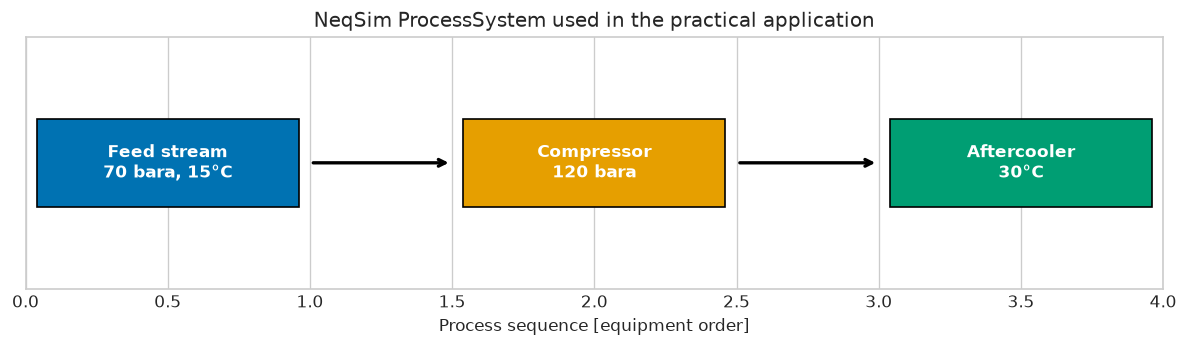

In [24]:
workflow_x = [0.5, 2.0, 3.5]
workflow_labels = [
    "Feed stream\n70 bara, 15°C",
    "Compressor\n120 bara",
    "Aftercooler\n30°C",
]
workflow_colors = [
    COLORS["blue"],
    COLORS["orange"],
    COLORS["green"],
]

fig, ax = plt.subplots(figsize=(10.0, 3.0))
for x_value, label, color in zip(
    workflow_x,
    workflow_labels,
    workflow_colors,
):
    equipment_box = plt.Rectangle(
        (x_value - 0.46, -0.28),
        0.92,
        0.56,
        facecolor=color,
        edgecolor="black",
        linewidth=1.0,
        zorder=3,
    )
    ax.add_patch(equipment_box)
    ax.text(
        x_value,
        0.0,
        label,
        ha="center",
        va="center",
        color="white",
        fontsize=10,
        weight="bold",
        zorder=4,
    )

for start, end in zip(workflow_x[:-1], workflow_x[1:]):
    ax.annotate(
        "",
        xy=(end - 0.50, 0.0),
        xytext=(start + 0.50, 0.0),
        arrowprops={"arrowstyle": "->", "linewidth": 2.0},
    )

ax.set_title("NeqSim ProcessSystem used in the practical application")
ax.set_xlim(0.0, 4.0)
ax.set_ylim(-0.8, 0.8)
ax.set_xlabel("Process sequence [equipment order]")
ax.set_yticks([])
plt.tight_layout()
plt.show()

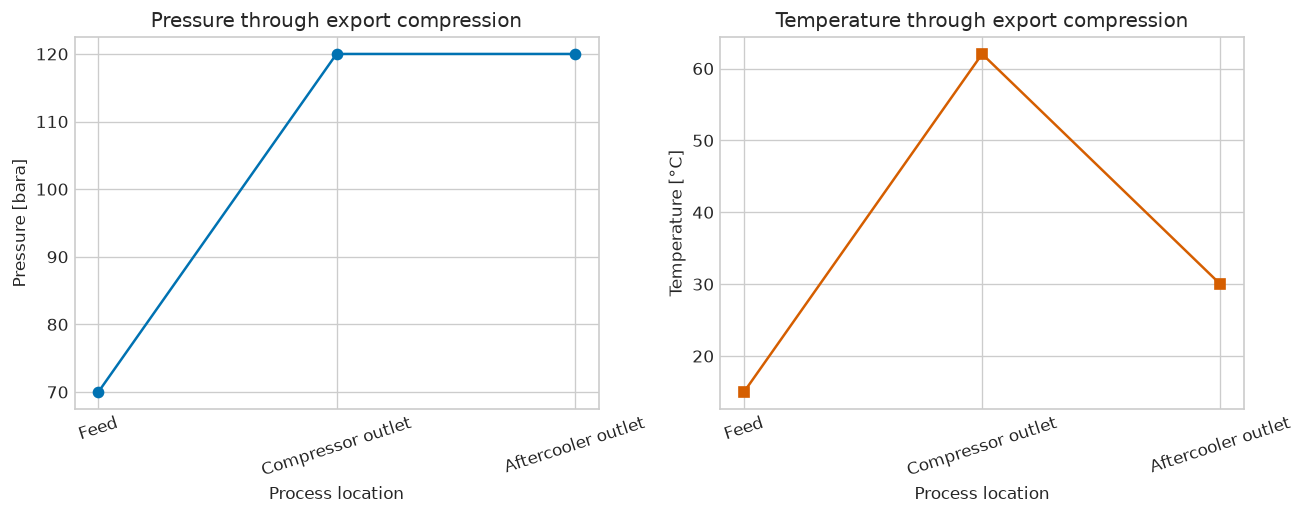

In [25]:
stage_results = pd.DataFrame(
    {
        "location": ["Feed", "Compressor outlet", "Aftercooler outlet"],
        "pressure_bara": [
            feed_stream.getPressure("bara"),
            export_compressor.getOutletStream().getPressure("bara"),
            aftercooler.getOutletStream().getPressure("bara"),
        ],
        "temperature_c": [
            feed_stream.getTemperature("C"),
            compressor_outlet_c,
            product_temperature_c,
        ],
    }
)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4))

axes[0].plot(
    stage_results["location"],
    stage_results["pressure_bara"],
    marker="o",
    color=COLORS["blue"],
)
axes[0].set_title("Pressure through export compression")
axes[0].set_xlabel("Process location")
axes[0].set_ylabel("Pressure [bara]")
axes[0].tick_params(axis="x", rotation=18)

axes[1].plot(
    stage_results["location"],
    stage_results["temperature_c"],
    marker="s",
    color=COLORS["red"],
)
axes[1].set_title("Temperature through export compression")
axes[1].set_xlabel("Process location")
axes[1].set_ylabel("Temperature [°C]")
axes[1].tick_params(axis="x", rotation=18)

fig.tight_layout()
plt.show()

**Interpretation.** Compression raises both pressure and temperature. Cooling removes that heat
before transport. NeqSim objects remain reusable: change composition, flow, pressure, efficiency,
or cooler temperature; rerun the same `ProcessSystem`; then retrieve updated results.

## 14. Connect the 2025 statistic to thermodynamic energy

Using the representative ISO 6976 LHV, the screening fuel energy from annual standard volume is:

$$
E_{PJ} = V_{bcm} H_{i,s}
$$

$V_{bcm}$ is bcm/year, $H_{i,s}$ is $\mathrm{MJ/Sm^3}$, and the result is PJ/year.
This conversion assumes the representative composition applies to the entire volume.

In [26]:
norway_gas_sales_2025_bcm = 121.8
fuel_energy_2025_pj = (
    norway_gas_sales_2025_bcm
    * lhv_mj_per_sm3
)

annual_useful_energy = end_uses.copy()
annual_useful_energy["useful_energy_pj"] = (
    annual_useful_energy["efficiency"] * fuel_energy_2025_pj
)

print(f"Representative 2025 gas LHV energy: {fuel_energy_2025_pj:,.1f} PJ/year")
display(annual_useful_energy[["end_use", "useful_energy_pj"]])

assert 4000.0 < fuel_energy_2025_pj < 5000.0

Representative 2025 gas LHV energy: 4,379.0 PJ/year


,end_use,useful_energy_pj
0,Condensing heat,4028.704273
1,Combined-cycle power,2539.835302
2,Industrial furnace,3590.801635
3,Hydrogen via SMR,3240.479524


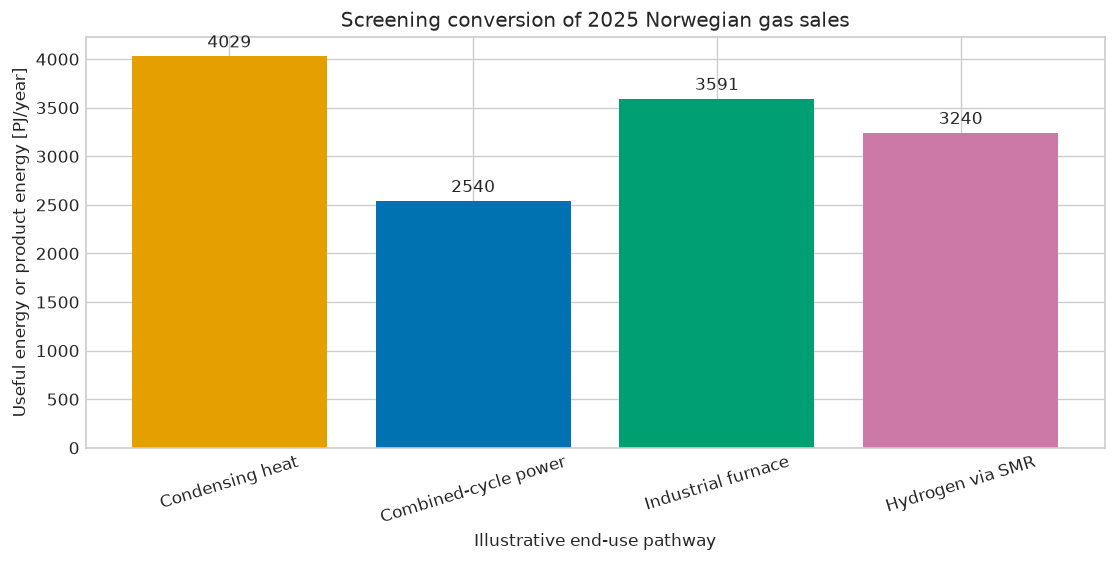

In [27]:
fig, ax = plt.subplots(figsize=(9.4, 4.8))

bars = ax.bar(
    annual_useful_energy["end_use"],
    annual_useful_energy["useful_energy_pj"],
    color=[
        COLORS["orange"],
        COLORS["blue"],
        COLORS["green"],
        COLORS["purple"],
    ],
)
ax.bar_label(bars, fmt="%.0f", padding=3)
ax.set_title("Screening conversion of 2025 Norwegian gas sales")
ax.set_xlabel("Illustrative end-use pathway")
ax.set_ylabel("Useful energy or product energy [PJ/year]")
ax.tick_params(axis="x", rotation=17)
plt.tight_layout()
plt.show()

**Interpretation.** This is a scale translation, not an allocation forecast: the same annual gas
volume is independently applied to each end-use efficiency. Real gas composition and sales vary,
and no claim is made that all Norwegian gas follows one pathway.

## 15. Sensitivity to methane dilution

Adding nitrogen while renormalising combustible components lowers volumetric calorific value.
The reusable function below rebuilds and flashes each fluid, then calls the same ISO 6976 API.
This demonstrates how a statistics-to-energy conversion depends on gas quality.

In [28]:
def calculate_lhv_with_nitrogen(nitrogen_fraction):
    base_without_nitrogen = {
        key: value
        for key, value in composition.items()
        if key != "nitrogen"
    }
    scale = (1.0 - nitrogen_fraction) / sum(base_without_nitrogen.values())

    sensitivity_fluid = fluid(
        "srk",
        temperature=288.15,
        pressure=70.0,
    )
    for component_name, mole_fraction in base_without_nitrogen.items():
        sensitivity_fluid.addComponent(
            component_name,
            mole_fraction * scale,
        )
    sensitivity_fluid.addComponent(
        "nitrogen",
        nitrogen_fraction,
    )
    sensitivity_fluid.setMixingRule("classic")
    TPflash(sensitivity_fluid)

    standard = ISO6976(
        sensitivity_fluid,
        numberunit="volume",
        referencetemperaturevolume="15",
        referencetemperaturecombustion="15",
    )
    return standard.getValue("InferiorCalorificValue") / 1000.0


nitrogen_grid = np.linspace(0.0, 0.08, 9)
lhv_grid = np.array(
    [
        calculate_lhv_with_nitrogen(nitrogen_fraction)
        for nitrogen_fraction in nitrogen_grid
    ]
)

assert np.all(np.diff(lhv_grid) < 0.0)

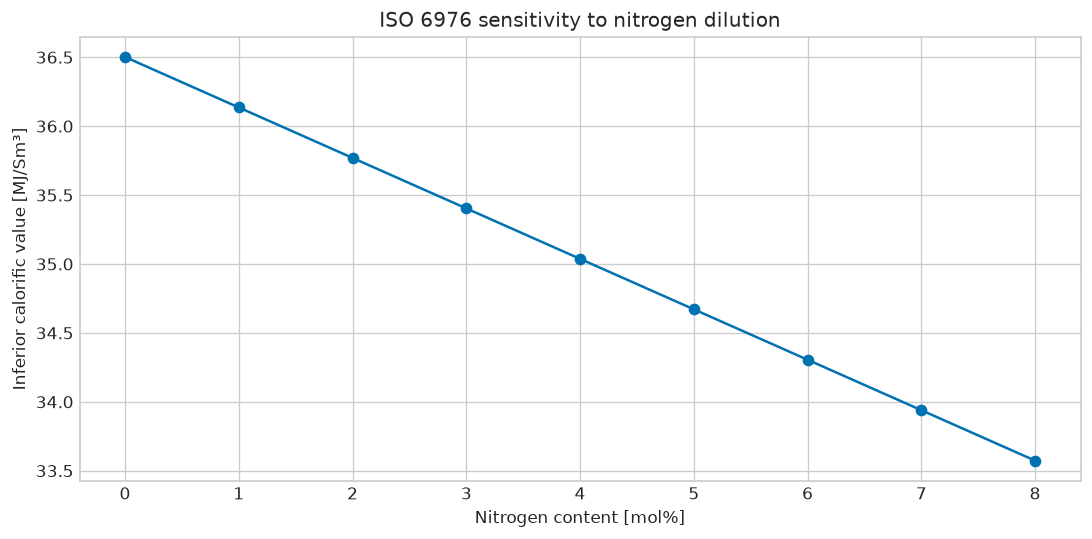

In [29]:
fig, ax = plt.subplots(figsize=(9.2, 4.6))

ax.plot(
    100.0 * nitrogen_grid,
    lhv_grid,
    marker="o",
    color=COLORS["blue"],
)
ax.set_title("ISO 6976 sensitivity to nitrogen dilution")
ax.set_xlabel("Nitrogen content [mol%]")
ax.set_ylabel("Inferior calorific value [MJ/Sm³]")
plt.tight_layout()
plt.show()

**Interpretation.** Standard volume is not an energy unit. A custody-transfer or national energy
calculation should use measured composition and declared reference conditions rather than a fixed
rule-of-thumb conversion.

## Validation summary

The notebook checks:

- all embedded shares and mole fractions are internally consistent;
- observations and forecasts remain explicitly labelled;
- the representative gas is single phase at the stated inlet condition;
- ISO 6976 results lie within broad natural-gas screening bounds;
- HHV exceeds LHV and Wobbe index exceeds HHV on a volume basis;
- compression power is positive and cooler duty removes heat;
- process inlet and outlet mass flows match;
- the compressor enthalpy-rate balance closes; and
- nitrogen dilution lowers volumetric LHV monotonically.

These checks verify implementation consistency, not plant design suitability.

In [30]:
validation_checks = {
    "composition closes": abs(composition_sum - 1.0) < 1.0e-12,
    "single gas phase": phase_count == 1,
    "LHV volume plausible": 30.0 < lhv_mj_per_sm3 < 45.0,
    "HHV above LHV": hhv_mj_per_sm3 > lhv_mj_per_sm3,
    "positive compressor power": compressor_power_mw > 0.0,
    "cooling duty removes heat": cooler_duty_mw < 0.0,
    "mass balance closes": abs(mass_residual_kg_s) < 1.0e-10,
    "compressor energy closes": abs(compressor_energy_residual_w) < 1.0e-6,
    "nitrogen sensitivity monotonic": bool(np.all(np.diff(lhv_grid) < 0.0)),
    "2025 energy scale plausible": 4000.0 < fuel_energy_2025_pj < 5000.0,
}

validation_table = pd.DataFrame(
    {
        "check": validation_checks.keys(),
        "passed": validation_checks.values(),
    }
)
display(validation_table)

assert validation_table["passed"].all()
print(f"All {len(validation_checks)} final validation checks passed.")

All 10 final validation checks passed.


,check,passed
0,composition closes,True
1,single gas phase,True
2,LHV volume plausible,True
3,HHV above LHV,True
4,positive compressor power,True
5,cooling duty removes heat,True
6,mass balance closes,True
7,compressor energy closes,True
8,nitrogen sensitivity monotonic,True
9,2025 energy scale plausible,True


## Limitations and applicability

- Global demand statistics are revised; always retain source date and evidence status.
- The Q3-2026 outlook is conditional on a disrupted market and can change quickly.
- Historical export snapshots preserve the original notebook but are not current trade data.
- The representative composition is synthetic and unsuitable for custody transfer.
- SRK is a screening model for dry gas; wet and associating systems need a suitable model.
- The compressor excludes a detailed performance map, mechanical losses, drivers, piping,
  recycle, surge protection, and availability.
- End-use efficiencies are assumptions; lifecycle comparisons need upstream methane,
  electricity, capture, transport, construction, and temporal boundaries.
- Resource volumes do not imply economically recoverable reserves or future demand.

## Troubleshooting

- **Package mismatch:** rerun the setup cell in a clean Colab runtime.
- **Java startup error:** restart the runtime once after an interrupted Java bridge import.
- **Fluid is multiphase:** inspect temperature, pressure, composition, and model choice.
- **Unexpected calorific value:** verify mass versus volume reference type and reference temperature.
- **Compressor does not converge:** start with a smaller pressure ratio and check inlet phase.
- **Negative cooler duty:** this is expected here; heat leaves the process material stream.
- **Statistics disagree:** compare year, standard conditions, gross/net trade, and revision date.

## Summary

Natural gas remains a large but highly heterogeneous part of the energy system. Recent annual
growth slowed and the current 2026 forecast is negative, illustrating why forecasts must be dated.
Norway sold 121.8 bcm in 2025 after a 124 bcm record in 2024.

All original Norwegian analyses were retained as reproducible historical snapshots. The final
application showed how NeqSim turns composition and operating conditions into ISO 6976 gas quality,
a composable compression process, balance checks, and an energy-scale interpretation of a reported
standard volume.

## Further exercises

1. Replace the representative composition with a public gas assay and compare LHV and Wobbe index.
2. Add water and compare SRK with CPA for a wet-gas screening case.
3. Build three compression stages with intercooling and compare total power.
4. Replace the illustrative future indices with a cited scenario dataset.
5. Add methane intensity and calculate lifecycle $\mathrm{CO_2e}$ per MWh of useful output.
6. Retrieve a current SODIR dataset, cache it with its publication date, and compare revisions.
7. Add a compressor map and screen operating distance from surge and stonewall.

## Authoritative references

- [IEA, Global Energy Review 2025: Natural gas](https://www.iea.org/reports/global-energy-review-2025/natural-gas), published 2025.
- [IEA, Global Energy Review 2026: Natural gas](https://www.iea.org/reports/global-energy-review-2026/natural-gas), published 2026.
- [IEA, Gas Market Report Q3-2026: Executive summary](https://www.iea.org/reports/gas-market-report-q3-2026/executive-summary), accessed 23 July 2026.
- [Norwegian Offshore Directorate, production figures December 2025](https://www.sodir.no/en/whats-new/news/production-figures/2026/production-figures-december-2025/), published 20 January 2026.
- [Norwegian Offshore Directorate, record-high gas production in 2024](https://www.sodir.no/en/whats-new/news/general-news/2025/record-high-gas-production-in-2024/), published 9 January 2025.
- [Norwegian Offshore Directorate, Resource Accounts 2025](https://www.sodir.no/en/whats-new/news/general-news/2026/high-production-and-increase-in-petroleum-resources/), published 20 February 2026.
- [NeqSim process simulation guide](https://equinor.github.io/neqsim/process/README.html).
- [NeqSim ISO 6976 gas-quality guide](https://equinor.github.io/neqsim/standards/iso6976_calorific_values.html).
- ISO 6976:2016, calculation of calorific values, density, relative density, and Wobbe indices from composition.